In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import plotly.express as px
import warnings
import certifi

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv(r"TaxiNYC.csv")
df

,Unnamed: 0,timestamp,value
0,0,2014-07-01 00:00:00,10844
1,1,2014-07-01 00:30:00,8127
2,2,2014-07-01 01:00:00,6210
3,3,2014-07-01 01:30:00,4656
4,4,2014-07-01 02:00:00,3820
...,...,...,...
10315,10315,2015-01-31 21:30:00,24670
10316,10316,2015-01-31 22:00:00,25721
10317,10317,2015-01-31 22:30:00,27309
10318,10318,2015-01-31 23:00:00,26591


In [3]:
df = df.rename(columns={
    "Unnamed: 0":"Unique_ID",
    "value": "passengers"
})

In [4]:
df.columns

Index(['Unique_ID', 'timestamp', 'passengers'], dtype='object')

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unique_ID,10320.0,5159.50000,2979.271723,0.0,2579.75,5159.5,7739.25,10319.0
passengers,10320.0,15137.56938,6939.495808,8.0,10262.00,16778.0,19838.75,39197.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unique_ID   10320 non-null  int64 
 1   timestamp   10320 non-null  object
 2   passengers  10320 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 242.0+ KB


In [7]:
df.drop("Unique_ID",axis=1,inplace=True)

In [8]:
df

,timestamp,passengers
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820
...,...,...
10315,2015-01-31 21:30:00,24670
10316,2015-01-31 22:00:00,25721
10317,2015-01-31 22:30:00,27309
10318,2015-01-31 23:00:00,26591


In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
df

,timestamp,passengers
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820
...,...,...
10315,2015-01-31 21:30:00,24670
10316,2015-01-31 22:00:00,25721
10317,2015-01-31 22:30:00,27309
10318,2015-01-31 23:00:00,26591


In [10]:
df['difff'] = df['timestamp'].diff()
df['difff'].value_counts()

difff
0 days 00:30:00    10319
Name: count, dtype: int64

In [11]:
df

,timestamp,passengers,difff
0,2014-07-01 00:00:00,10844,NaT
1,2014-07-01 00:30:00,8127,0 days 00:30:00
2,2014-07-01 01:00:00,6210,0 days 00:30:00
3,2014-07-01 01:30:00,4656,0 days 00:30:00
4,2014-07-01 02:00:00,3820,0 days 00:30:00
...,...,...,...
10315,2015-01-31 21:30:00,24670,0 days 00:30:00
10316,2015-01-31 22:00:00,25721,0 days 00:30:00
10317,2015-01-31 22:30:00,27309,0 days 00:30:00
10318,2015-01-31 23:00:00,26591,0 days 00:30:00


In [12]:
# Looking for Missing timestamps.
full_range = pd.date_range(
    start=df['timestamp'].min(),
    end=df['timestamp'].max(),
    freq='30T'
)
missing = full_range.difference(df['timestamp'])
len(missing)

0

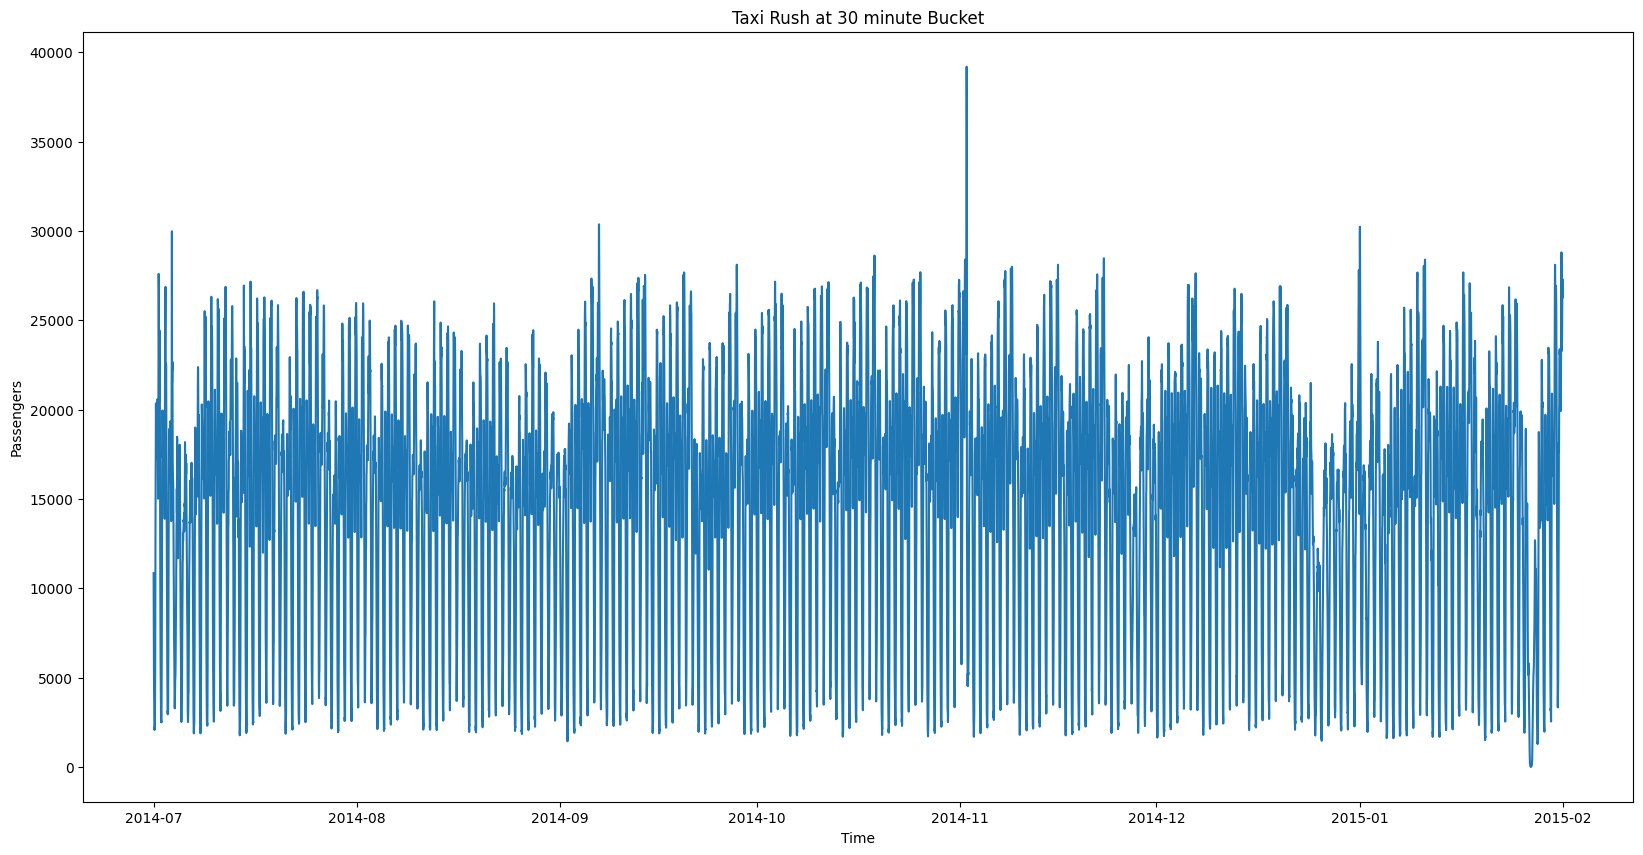

In [13]:
plt.figure(figsize=(20,10))
plt.plot(df['timestamp'], df['passengers'])
plt.title("Taxi Rush at 30 minute Bucket")
plt.ylabel("Passengers")
plt.xlabel("Time")
plt.show();

In [14]:
df.set_index('timestamp', inplace=True)

In [15]:
#Calendar features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['month'] = df.index.month

In [16]:
df

,passengers,difff,hour,day,weekday,month
timestamp,,,,,,
2014-07-01 00:00:00,10844,NaT,0,1,1,7
2014-07-01 00:30:00,8127,0 days 00:30:00,0,1,1,7
2014-07-01 01:00:00,6210,0 days 00:30:00,1,1,1,7
2014-07-01 01:30:00,4656,0 days 00:30:00,1,1,1,7
2014-07-01 02:00:00,3820,0 days 00:30:00,2,1,1,7
...,...,...,...,...,...,...
2015-01-31 21:30:00,24670,0 days 00:30:00,21,31,5,1
2015-01-31 22:00:00,25721,0 days 00:30:00,22,31,5,1
2015-01-31 22:30:00,27309,0 days 00:30:00,22,31,5,1


<Axes: title={'center': 'Avg Passengers by Hour'}, xlabel='hour'>

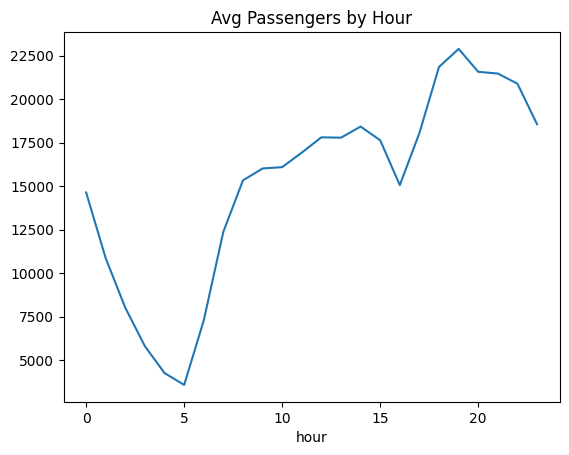

In [17]:
df.groupby('hour')['passengers'].mean().plot(
    title="Avg Passengers by Hour"
)

<Axes: title={'center': 'Avg Passengers by Day of Week'}, xlabel='weekday'>

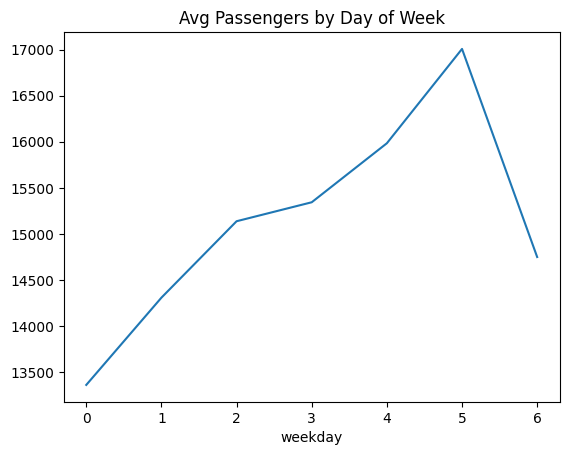

In [18]:
df.groupby('weekday')['passengers'].mean().plot(
    title="Avg Passengers by Day of Week"
)

In [19]:
#Rolling Mean and STD
df['rolling_mean_24'] = df['passengers'].rolling(48).mean()
df['rolling_std_24'] = df['passengers'].rolling(48).std()

In [20]:
df

,passengers,difff,hour,day,weekday,month,rolling_mean_24,rolling_std_24
timestamp,,,,,,,,
2014-07-01 00:00:00,10844,NaT,0,1,1,7,NaN,NaN
2014-07-01 00:30:00,8127,0 days 00:30:00,0,1,1,7,NaN,NaN
2014-07-01 01:00:00,6210,0 days 00:30:00,1,1,1,7,NaN,NaN
2014-07-01 01:30:00,4656,0 days 00:30:00,1,1,1,7,NaN,NaN
2014-07-01 02:00:00,3820,0 days 00:30:00,2,1,1,7,NaN,NaN
...,...,...,...,...,...,...,...,...
2015-01-31 21:30:00,24670,0 days 00:30:00,21,31,5,1,18715.645833,7616.169137
2015-01-31 22:00:00,25721,0 days 00:30:00,22,31,5,1,18694.437500,7594.738806
2015-01-31 22:30:00,27309,0 days 00:30:00,22,31,5,1,18703.500000,7604.959476


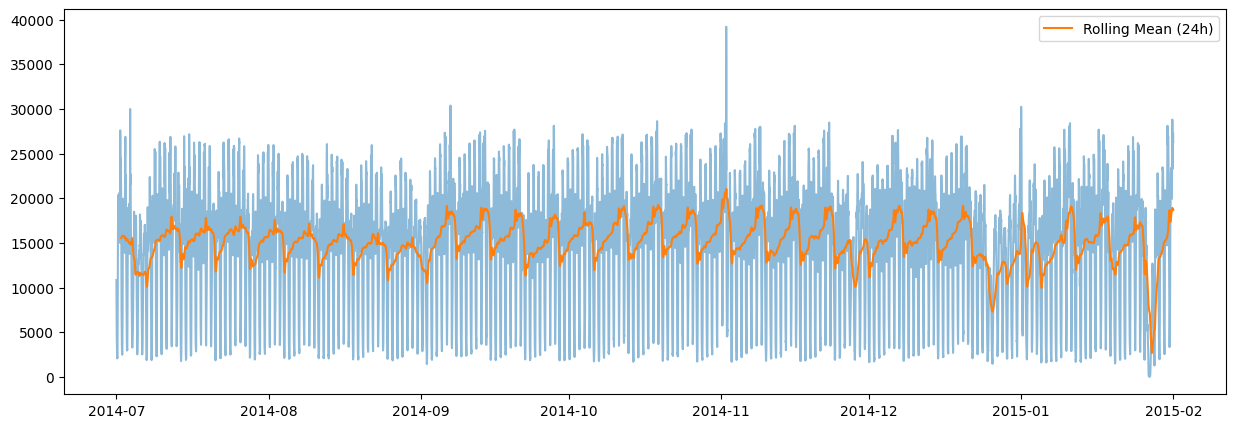

In [ ]:
#The orange line shows the AVG passenger count in the past 24 hours at every point of time.
plt.figure(figsize=(15,5))
plt.plot(df.index, df['passengers'], alpha=0.5)
plt.plot(df.index, df['rolling_mean_24'], label='Rolling Mean (24h)')
plt.legend()
plt.show()

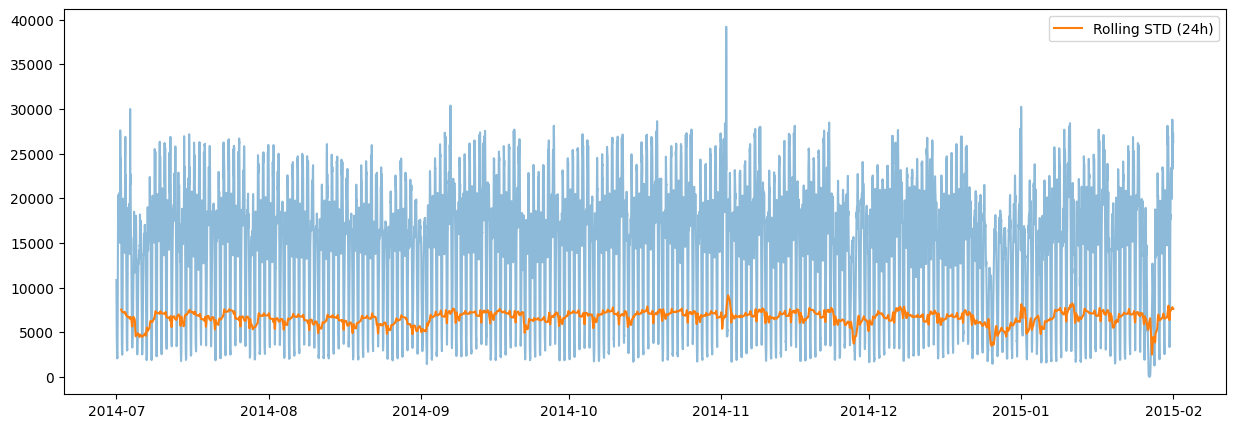

In [ ]:
#The orange line tells how much demand fluctuated in the last 24 hours.
# higher whem spikes happen and lower when the system is stable.
plt.figure(figsize=(15,5))
plt.plot(df.index, df['passengers'], alpha=0.5)
plt.plot(df.index, df['rolling_std_24'], label='Rolling STD (24h)')
plt.legend()
plt.show()

In [22]:
from scipy.stats import zscore

df['z'] = zscore(df['passengers'])
outliers = df[df['z'].abs() > 3]

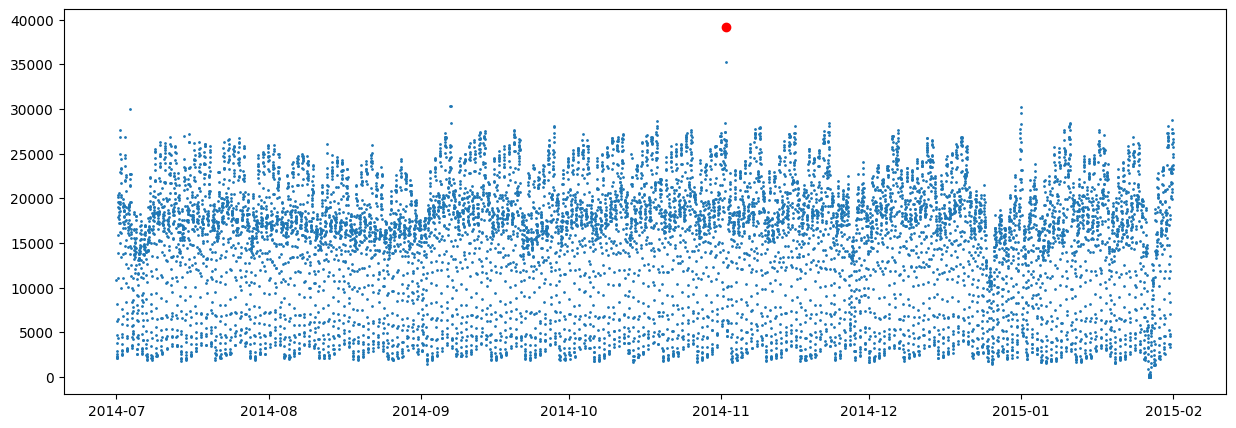

In [23]:
plt.figure(figsize=(15,5))
plt.scatter(df.index, df['passengers'], s=1)
plt.scatter(outliers.index, outliers['passengers'], color='red')
plt.show()

## Deduction :-

In [25]:
''' 
The NYC taxi dataset exhibits strong and consistent temporal seasonality at both daily and weekly levels.
Passenger demand follows a pronounced intra-day cycle, with minimal activity between 3 AM and 5 AM, a moderate morning commute surge, and a dominant evening peak between 6 PM and 9 PM.
Weekly aggregation reveals increasing demand toward the weekend, with Saturday representing the highest average ridership, indicating a significant leisure-driven component in taxi utilization.

The rolling 24-hour mean suggests a stable demand structure with a mild upward trend from July through November, followed by a temporary decline during late December and early January, likely attributable to seasonal or holiday-related effects. 
Rolling standard deviation analysis indicates generally stable volatility, with temporary spikes corresponding to extreme passenger surges and isolated demand collapses.

'''

' \nThe NYC taxi dataset exhibits strong and consistent temporal seasonality at both daily and weekly levels.\nPassenger demand follows a pronounced intra-day cycle, with minimal activity between 3 AM and 5 AM, a moderate morning commute surge, and a dominant evening peak between 6 PM and 9 PM.\nWeekly aggregation reveals increasing demand toward the weekend, with Saturday representing the highest average ridership, indicating a significant leisure-driven component in taxi utilization.\n\nThe rolling 24-hour mean suggests a stable demand structure with a mild upward trend from July through November, followed by a temporary decline during late December and early January, likely attributable to seasonal or holiday-related effects. \nRolling standard deviation analysis indicates generally stable volatility, with temporary spikes corresponding to extreme passenger surges and isolated demand collapses.\n\n'